# 14. Proyectos de grado dirigidos

**Fuente:** `data/raw/proyecto_grado.csv`  
**Salida:** `data/processed/proyecto_grado.csv`

Trabajos de titulacion dirigidos por el personal (director, tema, fecha de sustentacion, programa). El archivo de origen trae filas duplicadas.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd()))
import pandas as pd
import _preprocesamiento_comun as pc

pd.set_option('display.max_columns', 100)

## 1. Carga de datos crudos

In [2]:
df = pc.leer_csv('proyecto_grado.csv', low_memory=False)
df.head()

Leido proyecto_grado.csv con encoding=utf-8-sig -> 8169 filas, 8 columnas


,IDDIRECTOR,NOMBRETRABAJOTITULACION,FECHASUSTENTACION,NOMBREUNIDAD,NOMBREPROGRAMA,NUMPROMOCION,NIVELFORMACION,URLACTA
0,667930.0,Conteo de banano basados con aprendizaje profu...,2026-08-11,Facultad de Ingeniería en Ciencias de la Tierra,Maestría en Geomática,1,Maestría Profesional,NaN
1,94.0,ESTUDIO INTEGRAL PARA LA IMPLEMENTACIÓN DE UNA...,2026-08-07,Facultad de Ciencias Sociales y Humanísticas,Maestría en Economía y Dirección de Empresas,19,Maestría Profesional,NaN
2,94.0,ESTUDIO INTEGRAL PARA LA IMPLEMENTACIÓN DE UNA...,2026-08-07,Facultad de Ciencias Sociales y Humanísticas,Maestría en Economía y Dirección de Empresas,19,Maestría Profesional,NaN
3,649251.0,Control estructural sobre el comportamiento sí...,2026-08-06,Facultad de Ingeniería en Ciencias de la Tierra,Maestría en Geotecnia,5,Maestría Profesional,http://192.168.1.125/rest/bitstreams/2245822/r...
4,645561.0,Diseño de un sistema control de humedad y temp...,2026-08-06,Facultad de Ingeniería en Mecánica y Ciencias ...,Maestría en Ingeniería y Proyectos de Climatiz...,1,Maestría Profesional,http://192.168.1.125/rest/bitstreams/2244756/r...


## 2. Exploración inicial

In [3]:
pc.resumen(df, 'proyecto_grado')

--- Resumen proyecto_grado ---
Dimensiones: 8169 filas x 8 columnas
Filas duplicadas: 198
Columnas con nulos (%):
URLACTA       6.0
IDDIRECTOR    3.2
dtype: float64


In [4]:
df.dtypes

IDDIRECTOR                 float64
NOMBRETRABAJOTITULACION     object
FECHASUSTENTACION           object
NOMBREUNIDAD                object
NOMBREPROGRAMA              object
NUMPROMOCION                 int64
NIVELFORMACION              object
URLACTA                     object
dtype: object

## 3. Limpieza

In [5]:
df = pc.limpiar_strings(df)
df = pc.quitar_columnas_vacias(df, umbral=0.99)
df = pc.quitar_columnas_constantes(df)
n_antes = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f'Filas duplicadas eliminadas: {n_antes - len(df)}')

Filas duplicadas eliminadas: 198


In [6]:
df = df.drop(columns=['URLACTA'], errors='ignore')

## 5. Tipado de fechas e identificadores

In [7]:
df = pc.castear_fechas(df, ['FECHASUSTENTACION'])
df = pc.castear_enteros(df, ['IDDIRECTOR'])

## Gráficos exploratorios

Vistas rápidas para apoyar la construcción del catálogo de variables del perfil (Fase 1-2 de la metodología): estacionalidad/tendencia temporal, categorías dominantes y forma de la distribución de las variables numéricas.

In [8]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (9, 4)

**Proyectos de grado sustentados por año**.

<Axes: title={'center': 'Proyectos de grado sustentados por año'}, xlabel='Año', ylabel='N.º de registros'>

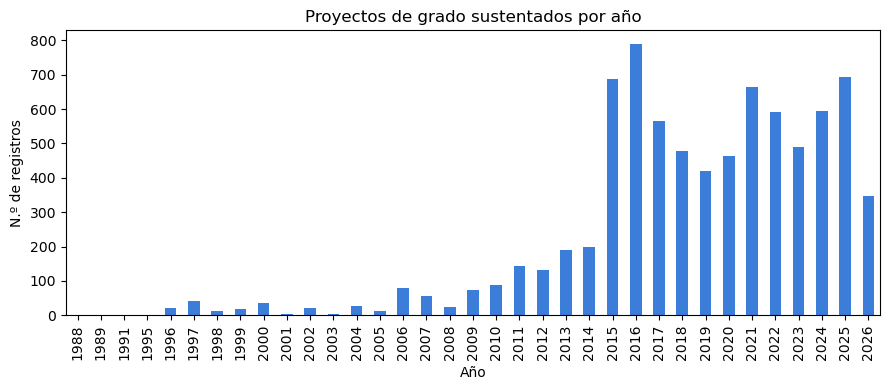

In [9]:
pc.grafico_por_anio(df['FECHASUSTENTACION'], 'Proyectos de grado sustentados por año')

**Programas con más proyectos de grado dirigidos**.

<Axes: title={'center': 'Top 10 programas por N.º de proyectos de grado'}, ylabel='NOMBREPROGRAMA'>

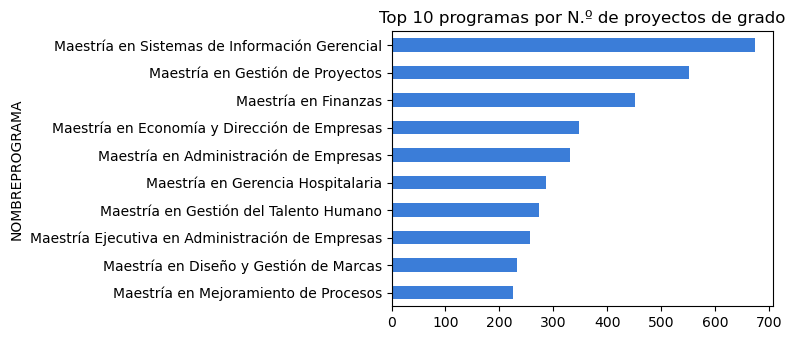

In [10]:
pc.grafico_barras(df['NOMBREPROGRAMA'], 'Top 10 programas por N.º de proyectos de grado', top=10)

**Nivel de formación** de los proyectos dirigidos (pregrado, maestría, doctorado).

<Axes: title={'center': 'Proyectos de grado por nivel de formación'}, xlabel='NIVELFORMACION'>

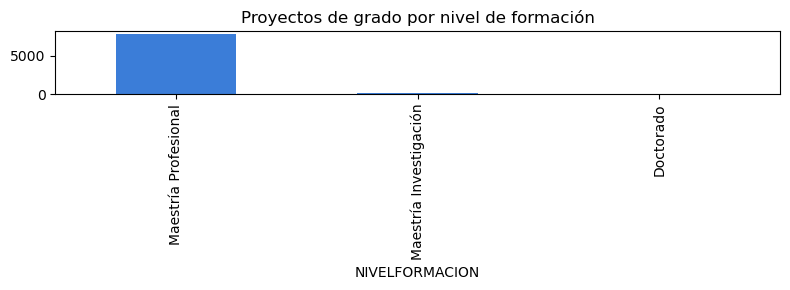

In [11]:
pc.grafico_barras(df['NIVELFORMACION'], 'Proyectos de grado por nivel de formación', horizontal=False)

## 7. Verificación final

In [12]:
pc.resumen(df, 'proyecto_grado (procesado)')
df.head()

--- Resumen proyecto_grado (procesado) ---
Dimensiones: 7971 filas x 7 columnas
Filas duplicadas: 1849
Columnas con nulos (%):
IDDIRECTOR    3.1
dtype: float64


,IDDIRECTOR,NOMBRETRABAJOTITULACION,FECHASUSTENTACION,NOMBREUNIDAD,NOMBREPROGRAMA,NUMPROMOCION,NIVELFORMACION
0,667930,Conteo de banano basados con aprendizaje profu...,2026-08-11,Facultad de Ingeniería en Ciencias de la Tierra,Maestría en Geomática,1,Maestría Profesional
1,94,ESTUDIO INTEGRAL PARA LA IMPLEMENTACIÓN DE UNA...,2026-08-07,Facultad de Ciencias Sociales y Humanísticas,Maestría en Economía y Dirección de Empresas,19,Maestría Profesional
2,649251,Control estructural sobre el comportamiento sí...,2026-08-06,Facultad de Ingeniería en Ciencias de la Tierra,Maestría en Geotecnia,5,Maestría Profesional
3,645561,Diseño de un sistema control de humedad y temp...,2026-08-06,Facultad de Ingeniería en Mecánica y Ciencias ...,Maestría en Ingeniería y Proyectos de Climatiz...,1,Maestría Profesional
4,638476,Modelo de Costeo y Definición de Pricing para ...,2026-08-06,Escuela de Postgrado en Administración de Empr...,Maestría en Analítica de Negocios,1,Maestría Profesional


## 8. Guardado en data/processed

In [13]:
pc.guardar_procesado(df, 'proyecto_grado.csv')

Guardado: D:\Proyecto_Tesis\data\processed\proyecto_grado.csv (7971 filas x 7 columnas)


WindowsPath('D:/Proyecto_Tesis/data/processed/proyecto_grado.csv')